In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
m = np.array([0.25,0.5,1,2,3,5,7,10,20,30])  # maturidades
y = np.array([0.02,0.021,0.022,0.024,0.025,0.027,0.028,0.029,0.030,0.031])  # tasas de interés

In [3]:
def nelson_siegel_factors(m, lam):
    
    f1 = np.ones(len(m))
    
    f2 = (1 - np.exp(-lam * m)) / (lam * m)
    
    f3 = f2 - np.exp(-lam * m)
    
    X = np.column_stack([f1, f2, f3])
    
    return X

In [5]:
lam = 0.5

X = nelson_siegel_factors(m, lam) 
X

array([[1.        , 0.94002478, 0.05752788],
       [1.        , 0.88479687, 0.10599608],
       [1.        , 0.78693868, 0.18040802],
       [1.        , 0.63212056, 0.26424112],
       [1.        , 0.51791323, 0.29478307],
       [1.        , 0.367166  , 0.285081  ],
       [1.        , 0.27708646, 0.24688908],
       [1.        , 0.19865241, 0.19191446],
       [1.        , 0.09999546, 0.09995006],
       [1.        , 0.06666665, 0.06666634]])

In [6]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
XtY = X.T @ y

beta_hat = XtX_inv @ XtY

beta_hat

array([ 0.03152962, -0.01201397, -0.00054267])

In [8]:
y_hat = X @ beta_hat

array([0.02020498, 0.02084218, 0.02197747, 0.02379195, 0.02514746,
       0.0269638 , 0.02806674, 0.02903887, 0.03027404, 0.03069251])

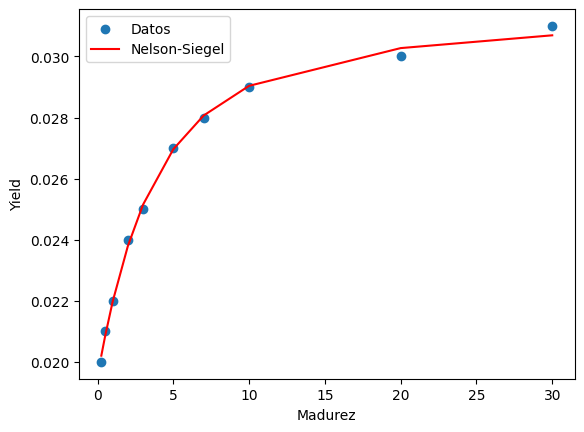

In [9]:
plt.scatter(m, y, label="Datos")
plt.plot(m, y_hat, label="Nelson-Siegel", color="red")
plt.xlabel("Madurez")
plt.ylabel("Yield")
plt.legend()
plt.show()

In [ ]:
df = pd.read_csv("rendimiento_tesoro_EEUU.csv")
df.head()

,Date,BETA0,BETA1,BETA2,BETA3,SVEN1F01,SVEN1F04,SVEN1F09,SVENF01,SVENF02,...,SVENY23,SVENY24,SVENY25,SVENY26,SVENY27,SVENY28,SVENY29,SVENY30,TAU1,TAU2
0,1961-06-14,3.917606,-1.277955,-1.949397,0.0,3.8067,3.9562,NaN,3.5492,3.8825,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.339218,-999.99
1,1961-06-15,3.978498,-1.257404,-2.247617,0.0,3.8694,4.0183,NaN,3.5997,3.9460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.325775,-999.99
2,1961-06-16,3.984350,-1.429538,-1.885024,0.0,3.8634,4.0242,NaN,3.5957,3.9448,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.348817,-999.99
3,1961-06-19,4.004379,-0.723311,-3.310743,0.0,3.9196,4.0447,NaN,3.6447,3.9842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282087,-999.99
4,1961-06-20,3.985789,-0.900432,-2.844809,0.0,3.8732,4.0257,NaN,3.5845,3.9552,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.310316,-999.99


In [ ]:
cols = [
"SVENY01","SVENY02","SVENY03","SVENY05",
"SVENY07","SVENY10","SVENY20","SVENY30"
]

row = df.iloc[-1]

y = row[cols].values / 100

m = np.array([1,2,3,5,7,10,20,30])

In [49]:
cols = [
    "SVENY01", "SVENY02", "SVENY03", "SVENY05",
    "SVENY07", "SVENY10", "SVENY20", "SVENY30",
]

m_map = {
    "SVENY01": 1,
    "SVENY02": 2,
    "SVENY03": 3,
    "SVENY05": 5,
    "SVENY07": 7,
    "SVENY10": 10,
    "SVENY20": 20,
    "SVENY30": 30,
}

# Toma las ultimas 100 fechas completas para obtener 800x2 (100x8)
df_100 = df[cols].dropna().tail(100).copy()

curve_df = (
    df_100
    .rename(columns=m_map)
    .melt(var_name="maturity", value_name="yield")
    .reset_index(drop=True)
)

curve_df["maturity"] = curve_df["maturity"].astype(int)
curve_df["yield"] = pd.to_numeric(curve_df["yield"], errors="coerce") / 100
curve_df = curve_df.sort_values("maturity").reset_index(drop=True)

# Arrays para el ajuste
m = curve_df["maturity"].to_numpy()
y = curve_df["yield"].to_numpy()

curve_df.shape, curve_df.head()

((800, 2),
    maturity     yield
 0         1  0.036720
 1         1  0.036218
 2         1  0.035929
 3         1  0.036094
 4         1  0.035551)

In [53]:
tao=1
X = nelson_siegel_factors(m, tao)
X
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
beta_hat

array([ 0.04964284,  0.0070974 , -0.06637311])

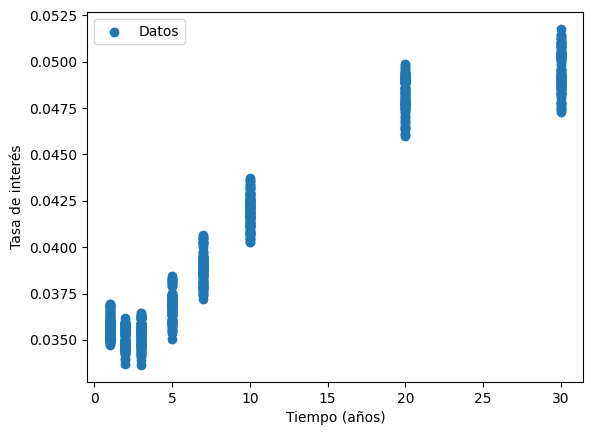

In [ ]:
plt.scatter(m, y, label="Datos")
plt.plot(m, X @ beta_hat, label="Ajuste Nelson-Siegel")
plt.xlabel("Tiempo (años)")
plt.ylabel("Tasa de interés")
plt.legend()
plt.show()

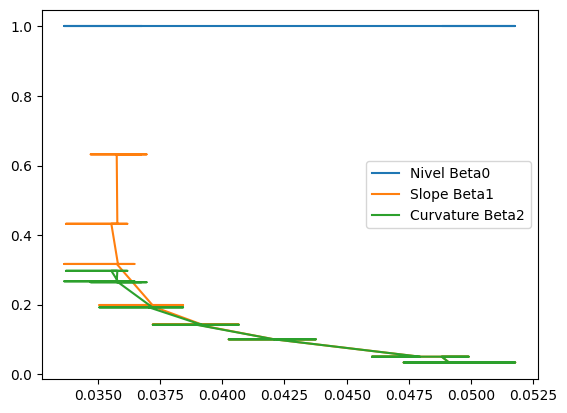

In [55]:
plt.plot(y, X[:,0], label="Nivel Beta0")
plt.plot(y, X[:,1], label="Slope Beta1")
plt.plot(y, X[:,2], label="Curvature Beta2")

plt.legend()
plt.show()